## Muhammad Rizqi Nurrohmat - 0110224001
## Machine Learning - Latihan Mandiri 11 - ***Analisis Pola Kelompok Menggunakan Metode DBSCAN pada Dataset Mall Customers***

### 1. Import Library

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

### 2. Load Dataset

In [9]:
df = pd.read_csv('../data/mall_customers.csv')
df.head()

,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3. Eksplorasi Data

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     200 non-null    int64 
 1   gender          200 non-null    object
 2   age             200 non-null    int64 
 3   annual_income   200 non-null    int64 
 4   spending_score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### 4. Fitur untuk Clustering

In [11]:
X = df[["annual_income", "spending_score"]].values

### 5. Standarisasi Data

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 6. Menjalankan DBSCAN

In [16]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

df["Cluster"] = clusters
df.head(10)

,customer_id,gender,age,annual_income,spending_score,Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,2
5,6,Female,22,17,76,0
6,7,Female,35,18,6,1
7,8,Female,23,18,94,-1
8,9,Male,64,19,3,1
9,10,Female,30,19,72,0


### 7. Visualisasi Hasil Cluster

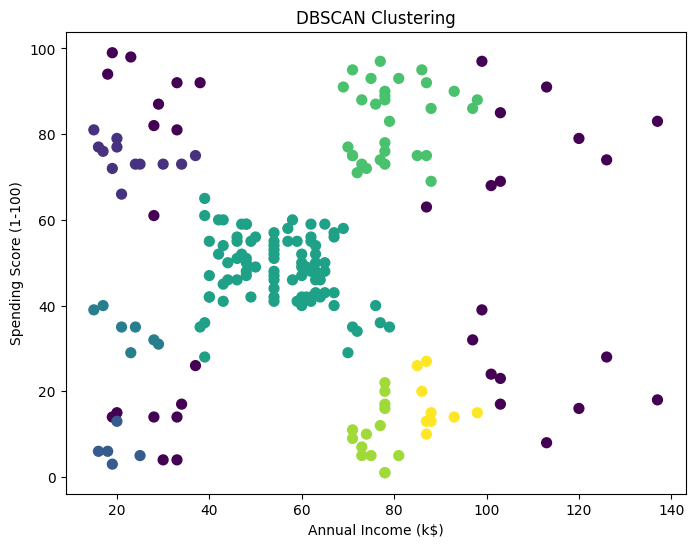

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["annual_income"],
    df["spending_score"],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")
plt.show()

### 8. Ringkasan Hasil

In [20]:
df["Cluster"].value_counts()

Cluster
 3    88
-1    35
 4    30
 5    14
 0    12
 6     9
 2     7
 1     5
Name: count, dtype: int64

### Kesimpulan Secara Keseluruhan

Secara keseluruhan, DBSCAN berhasil memetakan berbagai kelompok pelanggan berdasarkan pendapatan dan pola pengeluaran. Hasil ini menunjukkan bahwa:

1. Ada segmen pelanggan yang sangat potensial (pendapatan tinggi + pengeluaran tinggi).
2. Ada segmen yang kaya tapi hemat.
3. Ada segmen menengah yang stabil.
4. Ada pelanggan ekstrem yang masuk noise.